In [41]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## Pregunta 1

## 1

archivo = Path("/content/BaseInt.xlsx")

try:
    df_2005 = pd.read_excel(archivo, sheet_name="Base2005", engine="openpyxl")
    print("\nBase2005 cargada con éxito. Primeras filas:")
    print(df_2005.head())
except Exception as e:
    print("Error leyendo la hoja 'Base2005':", e)
    raise

try:
    df_2025 = pd.read_excel(archivo, sheet_name="Base2025", engine="openpyxl")
    print("\nBase2025 cargada con éxito. Primeras filas:")
    print(df_2025.head())
except Exception as e:
    print("Error leyendo la hoja 'Base2025':", e)
    raise



Base2005 cargada con éxito. Primeras filas:
   CODUSU  nro_hogar componente h15  ano4       trimestre    region mas_500  \
0  125099          1          1  Sí  2005  1er. Trimestre  Pampeana       N   
1  125099          1          2  Sí  2005  1er. Trimestre  Pampeana       N   
2  125099          1          3  Sí  2005  1er. Trimestre  Pampeana       N   
3  125156          1          1  Sí  2005  1er. Trimestre  Pampeana       N   
4  125575          1          1  Sí  2005  1er. Trimestre  Pampeana       N   

             aglomerado  pondera  ... deccfr ideccfr rdeccfr gdeccfr pdeccfr  \
0  Bahía Blanca - Cerri      256  ...      4       5       4     NaN       5   
1  Bahía Blanca - Cerri      256  ...      4       5       4     NaN       5   
2  Bahía Blanca - Cerri      256  ...      4       5       4     NaN       5   
3  Bahía Blanca - Cerri      270  ...     10      10      10     NaN      10   
4  Bahía Blanca - Cerri      199  ...      3       3       3     NaN       4   


<Figure size 800x600 with 0 Axes>

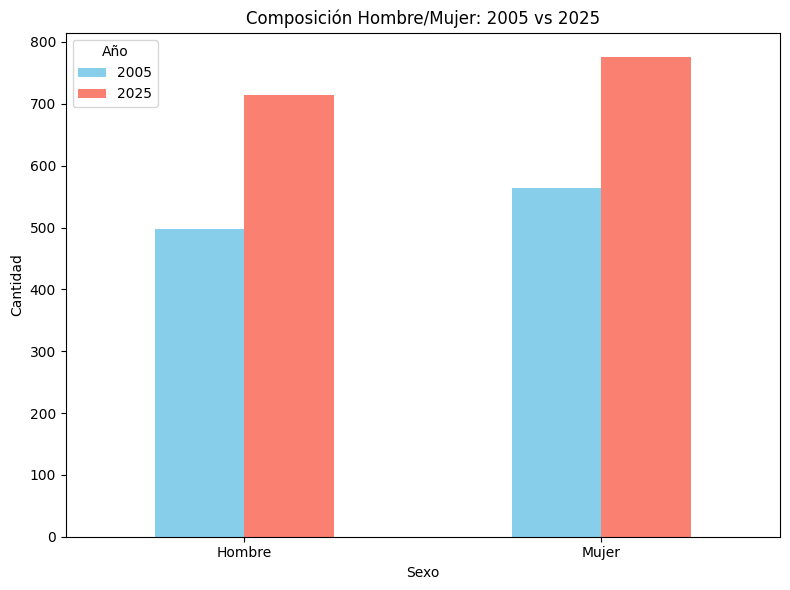

In [42]:
## 2.c



def detect_column(df, candidates):
    """Buscar la primera columna de 'candidates' presente en df (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def make_sex_series(series):
    """Normaliza una serie que contiene sexo (texto o códigos 1/2) y devuelve etiquetas 'Hombre'/'Mujer'."""
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        s = s.replace({1: 'Hombre', 2: 'Mujer'})
    else:
        s = s.astype(str).str.strip()
        s = s.replace({
            'Varón': 'Hombre',
            'Varon': 'Hombre',
            'varón': 'Hombre',
            'varon': 'Hombre',
            'HOMBRE': 'Hombre',
            'MUJER': 'Mujer',
            'Hombre': 'Hombre',
            'Mujer': 'Mujer'
        })
    s = s.apply(lambda x: x.title() if x not in ['Hombre', 'Mujer'] else x)
    s = s.replace({'Nan': pd.NA, 'None': pd.NA})
    return s


candidate_cols = ['ch04', 'CH04']

col_sexo_2005 = detect_column(df_2005, candidate_cols)
if col_sexo_2005 is None:
    print("ERROR: No se pudo detectar una columna de sexo clara en Base2005.")
    sys.exit(1)

col_sexo_2025 = detect_column(df_2025, candidate_cols)
if col_sexo_2025 is None:
    print("ERROR: No se pudo detectar una columna de sexo clara en Base2025.")
    sys.exit(1)

df_2005['sexo_normalizado'] = make_sex_series(df_2005[col_sexo_2005])
df_2025['sexo_normalizado'] = make_sex_series(df_2025[col_sexo_2025])

conteo_2005 = df_2005['sexo_normalizado'].value_counts(dropna=True)
conteo_2025 = df_2025['sexo_normalizado'].value_counts(dropna=True)

df_comparacion = pd.DataFrame({
    '2005': conteo_2005,
    '2025': conteo_2025
})

categorias = ['Hombre', 'Mujer']
df_comparacion = df_comparacion.reindex(categorias, fill_value=0)

plt.figure(figsize=(8, 6))
df_comparacion.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Composición Hombre/Mujer: 2005 vs 2025')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Año')
plt.tight_layout()
plt.show()


In [43]:
## 2.d

print(df_2005.columns.tolist())

columnas_correlacion = [
    'ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf'
]

df_2005_corr = df_2005[columnas_correlacion].copy()
print("\nDataFrame df_2005_corr creado con las columnas seleccionadas. Primeras filas:")
print(df_2005_corr.head())


['CODUSU', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre', 'region', 'mas_500', 'aglomerado', 'pondera', 'ch03', 'ch04', 'ch06', 'ch07', 'ch08', 'ch09', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch15_cod', 'ch16', 'ch16_cod', 'nivel_ed', 'estado', 'cat_ocup', 'cat_inac', 'pp02c1', 'pp02c2', 'pp02c3', 'pp02c4', 'pp02c5', 'pp02c6', 'pp02c7', 'pp02c8', 'pp02e', 'pp02h', 'pp02i', 'pp03c', 'pp03d', 'pp3e_tot', 'pp3f_tot', 'pp03g', 'pp03h', 'pp03i', 'pp03j', 'intensi', 'pp04a', 'pp04b_cod', 'pp04b1', 'pp04b2', 'pp04b3_mes', 'pp04b3_ano', 'pp04b3_dia', 'pp04c', 'pp04c99', 'pp04d_cod', 'pp04g', 'pp05b2_mes', 'pp05b2_ano', 'pp05b2_dia', 'pp05c_1', 'pp05c_2', 'pp05c_3', 'pp05e', 'pp05f', 'pp05h', 'pp06a', 'pp06c', 'pp06d', 'pp06e', 'pp06h', 'pp07a', 'pp07c', 'pp07d', 'pp07e', 'pp07f1', 'pp07f2', 'pp07f3', 'pp07f4', 'pp07f5', 'pp07g1', 'pp07g2', 'pp07g3', 'pp07g4', 'pp07g_59', 'pp07h', 'pp07i', 'pp07j', 'pp07k', 'pp08d1', 'pp08d4', 'pp08f1', 'pp08f2', 'pp08j1', 'pp08j2', 'pp08j3', '

In [44]:
for col in df_2005_corr.columns:
    if df_2005_corr[col].dtype == 'object' or df_2005_corr[col].dtype.name == 'category':
        df_2005_corr[col], _ = pd.factorize(df_2005_corr[col])

for col in df_2005_corr.columns:
    df_2005_corr[col] = pd.to_numeric(df_2005_corr[col], errors='coerce')

df_2005_corr = df_2005_corr.fillna(df_2005_corr.mean(numeric_only=True))

print("df_2005_corr después de la conversión de categóricas a numéricas y manejo de NaNs:")
print(df_2005_corr.head())
print("Tipos de datos finales de df_2005_corr:")
print(df_2005_corr.dtypes)

df_2005_corr después de la conversión de categóricas a numéricas y manejo de NaNs:
   ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac         ipcf
0     0     0     0     0         0       0         0   266.666667
1     1     1     0     0         0       1         1   266.666667
2     0     2     1     0         1       1         2   266.666667
3     0     3     2     1         2       0         0  2500.000000
4     0     4     0     0         0       0         0   170.000000
Tipos de datos finales de df_2005_corr:
ch04          int64
ch06          int64
ch07          int64
ch08          int64
nivel_ed      int64
estado        int64
cat_inac      int64
ipcf        float64
dtype: object


Matriz de Correlación de Pearson para df_2005:

              ch04      ch06      ch07      ch08  nivel_ed    estado  \
ch04      1.000000  0.027897  0.065292  0.036160 -0.069087  0.118748   
ch06      0.027897  1.000000  0.042481  0.060946 -0.052483  0.080545   
ch07      0.065292  0.042481  1.000000  0.197195 -0.115860 -0.154565   
ch08      0.036160  0.060946  0.197195  1.000000  0.041594 -0.081758   
nivel_ed -0.069087 -0.052483 -0.115860  0.041594  1.000000  0.023645   
estado    0.118748  0.080545 -0.154565 -0.081758  0.023645  1.000000   
cat_inac  0.042489  0.126563 -0.062872  0.064022  0.003800  0.518251   
ipcf     -0.042689  0.006262  0.082150  0.208906 -0.000544 -0.133559   

          cat_inac      ipcf  
ch04      0.042489 -0.042689  
ch06      0.126563  0.006262  
ch07     -0.062872  0.082150  
ch08      0.064022  0.208906  
nivel_ed  0.003800 -0.000544  
estado    0.518251 -0.133559  
cat_inac  1.000000 -0.035976  
ipcf     -0.035976  1.000000  


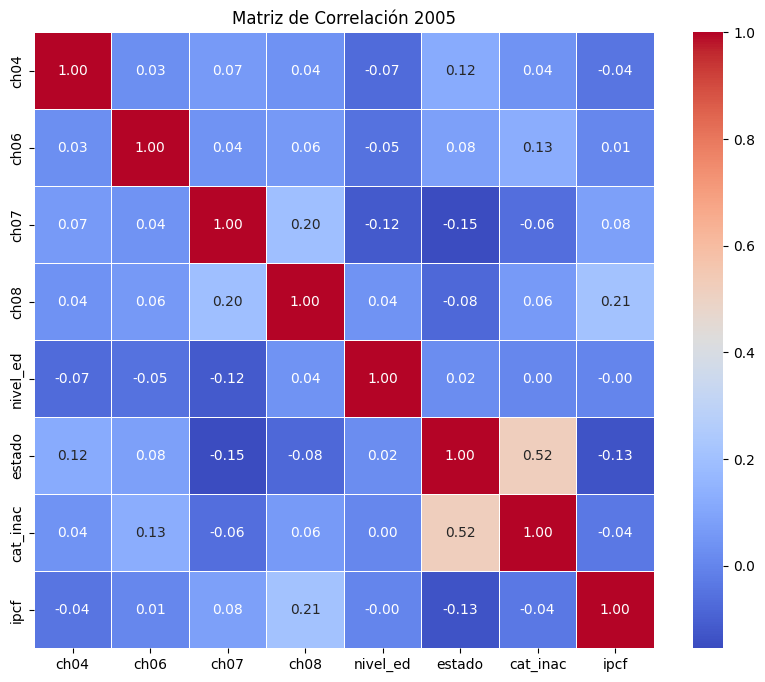

In [45]:
import seaborn as sns

correlation_matrix_2005 = df_2005_corr.corr(method='pearson')

print("Matriz de Correlación de Pearson para df_2005:\n")
print(correlation_matrix_2005)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_2005, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación 2005')
plt.show()

In [46]:
print(df_2025.columns.tolist())

columnas_correlacion_2025 = [
    'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF'
]

df_2025_corr = df_2025[columnas_correlacion_2025].copy()
print("\nDataFrame df_2025_corr creado con las columnas seleccionadas. Primeras filas:")
print(df_2025_corr.head())


['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH05', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'IMPUTA', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP

In [47]:
for col in df_2025_corr.columns:
    if df_2025_corr[col].dtype == 'object' or df_2025_corr[col].dtype.name == 'category':
        df_2025_corr[col], _ = pd.factorize(df_2025_corr[col])

for col in df_2025_corr.columns:
    df_2025_corr[col] = pd.to_numeric(df_2025_corr[col], errors='coerce')

df_2025_corr = df_2025_corr.fillna(df_2025_corr.mean(numeric_only=True))

print("df_2025_corr después de la conversión de categóricas a numéricas y manejo de NaNs:")
print(df_2025_corr.head())
print("Tipos de datos finales de df_2025_corr:")
print(df_2025_corr.dtypes)

df_2025_corr después de la conversión de categóricas a numéricas y manejo de NaNs:
   CH04  CH06  CH07  CH08  NIVEL_ED  ESTADO  CAT_INAC      IPCF
0     2    25     1     4         4       1         0  205600.0
1     2     7     5     4         1       4         3  205600.0
2     1     4     5     4         7       4         5  205600.0
3     2    29     5     4         5       1         0  230000.0
4     2    13     5     4         1       3         3  230000.0
Tipos de datos finales de df_2025_corr:
CH04          int64
CH06          int64
CH07          int64
CH08          int64
NIVEL_ED      int64
ESTADO        int64
CAT_INAC      int64
IPCF        float64
dtype: object


Matriz de Correlación de Pearson para df_2025:

              CH04      CH06      CH07      CH08  NIVEL_ED    ESTADO  \
CH04      1.000000  0.094318 -0.023367  0.007679  0.051570  0.110046   
CH06      0.094318  1.000000 -0.505533 -0.032956  0.090650 -0.265253   
CH07     -0.023367 -0.505533  1.000000  0.029944 -0.110091  0.395900   
CH08      0.007679 -0.032956  0.029944  1.000000  0.050961  0.017643   
NIVEL_ED  0.051570  0.090650 -0.110091  0.050961  1.000000 -0.223041   
ESTADO    0.110046 -0.265253  0.395900  0.017643 -0.223041  1.000000   
CAT_INAC  0.117982 -0.368719  0.345736 -0.001717 -0.135463  0.814296   
IPCF     -0.041181  0.136118 -0.053904 -0.019378  0.228037 -0.181811   

          CAT_INAC      IPCF  
CH04      0.117982 -0.041181  
CH06     -0.368719  0.136118  
CH07      0.345736 -0.053904  
CH08     -0.001717 -0.019378  
NIVEL_ED -0.135463  0.228037  
ESTADO    0.814296 -0.181811  
CAT_INAC  1.000000 -0.196998  
IPCF     -0.196998  1.000000  


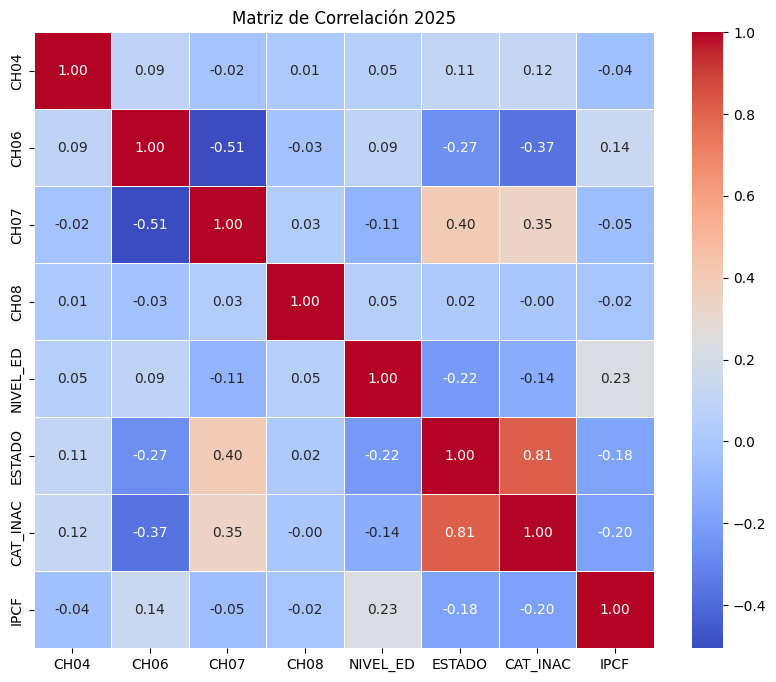

In [48]:
import seaborn as sns

correlation_matrix_2025 = df_2025_corr.corr(method='pearson')

print("Matriz de Correlación df_2025:\n")
print(correlation_matrix_2025)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_2025, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación 2025')
plt.show()

In [49]:
## 2.e

conteo_2005 = df_2005['estado'].value_counts()
print("Cantidad por estado (2005):")
print(conteo_2005)

Cantidad por estado (2005):
estado
Inactivo            457
Ocupado             431
Menor de 10 años    122
Desocupado           52
Name: count, dtype: int64


In [50]:
conteo_2025 = df_2025['ESTADO'].value_counts()
print("Cantidad por estado (2025):")
print(conteo_2025)

Cantidad por estado (2025):
ESTADO
1    642
3    630
4    163
2     55
Name: count, dtype: int64


In [51]:
media_ipcf_2005 = df_2005[df_2005['ipcf'] != -1].groupby('estado')['ipcf'].mean()
print("\nMedia IPCF (2005):")
print(media_ipcf_2005)


Media IPCF por estado (2005):
estado
Desocupado          387.294643
Inactivo            421.515005
Menor de 10 años    319.713603
Ocupado             564.866037
Name: ipcf, dtype: float64


In [54]:
media_ipcf_2025 = df_2025[df_2025['IPCF'] != -1].groupby('ESTADO')['IPCF'].mean()
print("\nMedia IPCF (2025):")
print(media_ipcf_2025)


Media IPCF (2025):
ESTADO
1    485861.561340
2    291836.632000
3    332889.700000
4    270967.952147
Name: IPCF, dtype: float64


In [62]:
# 3
no_respondieron_count = (df_2005['estado'] == 0).sum()
print(f"Cantidad de personas que no respondieron su estado: {no_respondieron_count}")


no_respondieron_count = (df_2025['ESTADO'] == 0).sum()
print(f"Cantidad de personas que no respondieron su estado: {no_respondieron_count}")

#### COMO TODOS RESPONDIERON, HACEMOS UNA SOLA BASE QUE CONSIDERE LA RESPUESTA DE LOS QUE RESPONDIERON.

estado_2005 = df_2005[['estado']]
estado_2025 = df_2025[['ESTADO']]

# Guardar en un nuevo Excel con hojas separadas
with pd.ExcelWriter("/content/respondieron.xlsx") as writer:
    estado_2005.to_excel(writer, sheet_name="2005", index=False)
    estado_2025.to_excel(writer, sheet_name="2025", index=False)


Cantidad de personas que no respondieron su estado: 0
Cantidad de personas que no respondieron su estado: 0


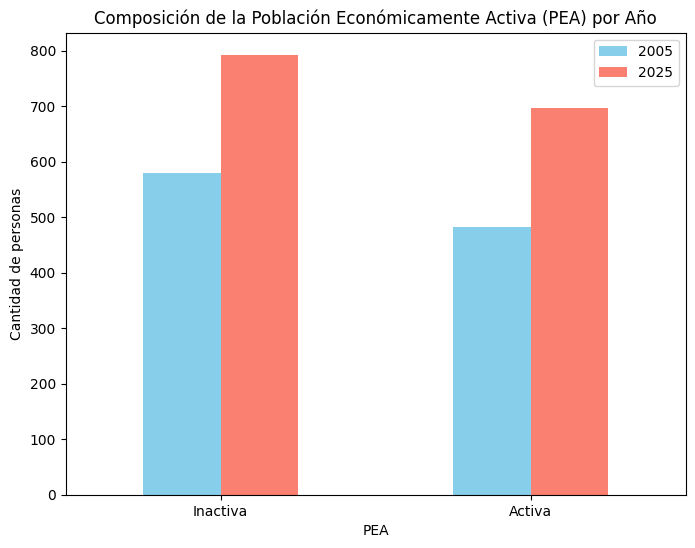

In [69]:
## 4

archivo = "/content/respondieron.xlsx"
df_2005 = pd.read_excel(archivo, sheet_name="2005")
df_2025 = pd.read_excel(archivo, sheet_name="2025")

df_2005['PEA'] = df_2005['estado'].apply(lambda x: 1 if x in ['Ocupado','Desocupado'] else 0)
df_2025['PEA'] = df_2025['ESTADO'].apply(lambda x: 1 if x in [1,2] else 0)

with pd.ExcelWriter("/content/respondieron.xlsx") as writer:
    df_2005.to_excel(writer, sheet_name="2005", index=False)
    df_2025.to_excel(writer, sheet_name="2025", index=False)

# --- Gráfico de barras: Activa vs Inactiva por año ---
# Contar activos e inactivos
conteo_2005 = df_2005['PEA'].value_counts().rename({1:'Activa', 0:'Inactiva'})
conteo_2025 = df_2025['PEA'].value_counts().rename({1:'Activa', 0:'Inactiva'})

# Crear DataFrame para graficar
pea_df = pd.DataFrame({
    '2005': conteo_2005,
    '2025': conteo_2025
})

# Gráfico
pea_df.plot(kind='bar', figsize=(8,6), color=['skyblue','salmon'])
plt.title("Composición de la Población Económicamente Activa (PEA) por Año")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=0)
plt.show()



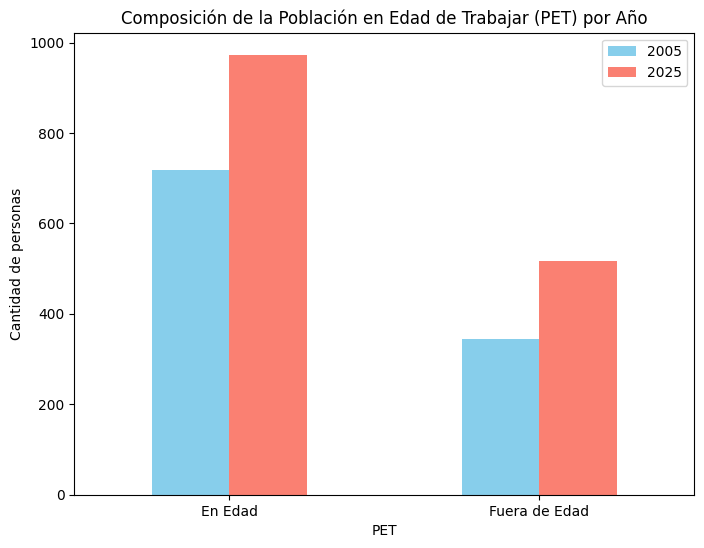

In [73]:
## 5
archivo_original = "/content/BaseInt.xlsx"
archivo_respondieron = "/content/respondieron.xlsx"

df_orig_2005 = pd.read_excel(archivo_original, sheet_name="Base2005")
df_orig_2025 = pd.read_excel(archivo_original, sheet_name="Base2025")

df_resp_2005 = pd.read_excel(archivo_respondieron, sheet_name="2005")
df_resp_2025 = pd.read_excel(archivo_respondieron, sheet_name="2025")

df_orig_2005['ch06'] = pd.to_numeric(df_orig_2005['ch06'], errors='coerce')
df_orig_2025['CH06'] = pd.to_numeric(df_orig_2025['CH06'], errors='coerce')

df_resp_2005['PET'] = df_orig_2005['ch06'].apply(lambda x: 1 if 15 <= x <= 65 else 0)
df_resp_2025['PET'] = df_orig_2025['CH06'].apply(lambda x: 1 if 15 <= x <= 65 else 0)

with pd.ExcelWriter("/content/respondieron.xlsx") as writer:
    df_resp_2005.to_excel(writer, sheet_name="2005", index=False)
    df_resp_2025.to_excel(writer, sheet_name="2025", index=False)


conteo_2005 = df_resp_2005['PET'].value_counts().rename({1:'En Edad', 0:'Fuera de Edad'})
conteo_2025 = df_resp_2025['PET'].value_counts().rename({1:'En Edad', 0:'Fuera de Edad'})

pea_df = pd.DataFrame({
    '2005': conteo_2005,
    '2025': conteo_2025
})

pea_df.plot(kind='bar', figsize=(8,6), color=['skyblue','salmon'])
plt.title("Composición de la Población en Edad de Trabajar (PET) por Año")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=0)
plt.show()



In [5]:
## 6

import pandas as pd


base_original = "/content/BaseInt.xlsx"
base_respondieron = "/content/respondieron (2).xlsx"

orig_2005 = pd.read_excel(base_original, sheet_name="Base2005")
orig_2025 = pd.read_excel(base_original, sheet_name="Base2025")


resp_2005 = pd.read_excel(base_respondieron, sheet_name="2005")
resp_2025 = pd.read_excel(base_respondieron, sheet_name="2025")



orig_2005['desocupado'] = (orig_2005['estado'] == 'Desocupado').astype(int)
orig_2025['desocupado'] = (orig_2025['ESTADO'] == 2).astype(int)



resp_2005['desocupado'] = orig_2005['desocupado']
resp_2025['desocupado'] = orig_2025['desocupado']



with pd.ExcelWriter("/content/respondieron.xlsx") as writer:
    resp_2005.to_excel(writer, sheet_name="2005", index=False)
    resp_2025.to_excel(writer, sheet_name="2025", index=False)






In [6]:
archivo = "/content/respondieron.xlsx"
df_2005 = pd.read_excel(archivo, sheet_name="2005")
df_2025 = pd.read_excel(archivo, sheet_name="2025")

# Contar desocupados (desocupado = 1)
desocupados_2005 = df_2005['desocupado'].sum()
desocupados_2025 = df_2025['desocupado'].sum()

print(f"Cantidad de desocupados en 2005: {desocupados_2005}")
print(f"Cantidad de desocupados en 2025: {desocupados_2025}")



Cantidad de desocupados en 2005: 52
Cantidad de desocupados en 2025: 55


/tmp/ipython-input-177847633.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("EDAD_GRUPO")["DESOCUPADO"]
/tmp/ipython-input-177847633.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("EDAD_GRUPO")["DESOCUPADO"]


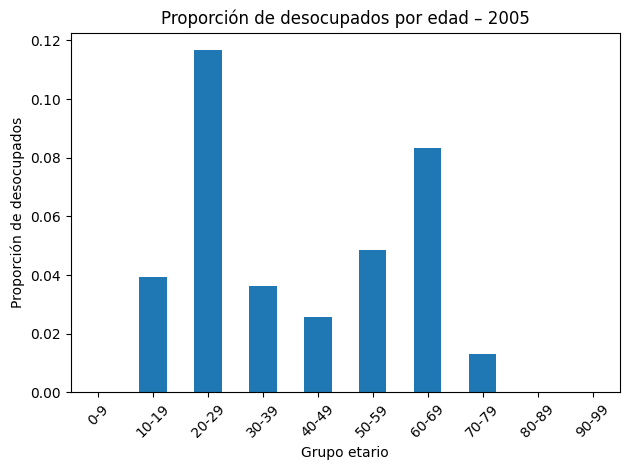

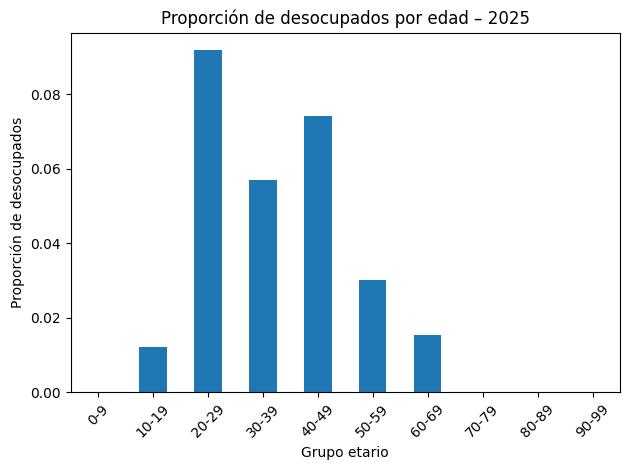

In [16]:

df_2005 = pd.read_excel("BaseInt.xlsx", sheet_name="Base2005")
df_2025 = pd.read_excel("BaseInt.xlsx", sheet_name="Base2025")

df_2005.columns = df_2005.columns.str.upper()
df_2025.columns = df_2025.columns.str.upper()

# Convert 'CH06' to numeric, coercing errors and filling NaNs
df_2005['CH06'] = pd.to_numeric(df_2005['CH06'], errors='coerce')
df_2005['CH06'] = df_2005['CH06'].fillna(df_2005['CH06'].mean())

df_2025['CH06'] = pd.to_numeric(df_2025['CH06'], errors='coerce')
df_2025['CH06'] = df_2025['CH06'].fillna(df_2025['CH06'].mean())

df_2005 = df_2005[(df_2005["CH06"] >= 0) & (df_2005["CH06"] <= 100)]
df_2025 = df_2025[(df_2025["CH06"] >= 0) & (df_2025["CH06"] <= 100)]


bins = list(range(0, 101, 10))
labels = [f"{i}-{i+9}" for i in bins[:-1]]

df_2005["EDAD_GRUPO"] = pd.cut(df_2005["CH06"], bins=bins, labels=labels, right=False)
df_2025["EDAD_GRUPO"] = pd.cut(df_2025["CH06"], bins=bins, labels=labels, right=False)


edad_2005 = (
    df_2005
    .groupby("EDAD_GRUPO")["DESOCUPADO"]
    .mean()
    .sort_index()
)

edad_2025 = (
    df_2025
    .groupby("EDAD_GRUPO")["DESOCUPADO"]
    .mean()
    .sort_index()
)


plt.figure()
edad_2005.plot(kind="bar")
plt.title("Proporción de desocupados por edad – 2005")
plt.xlabel("Grupo etario")
plt.ylabel("Proporción de desocupados")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
edad_2025.plot(kind="bar")
plt.title("Proporción de desocupados por edad – 2025")
plt.xlabel("Grupo etario")
plt.ylabel("Proporción de desocupados")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
